In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "ic" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"


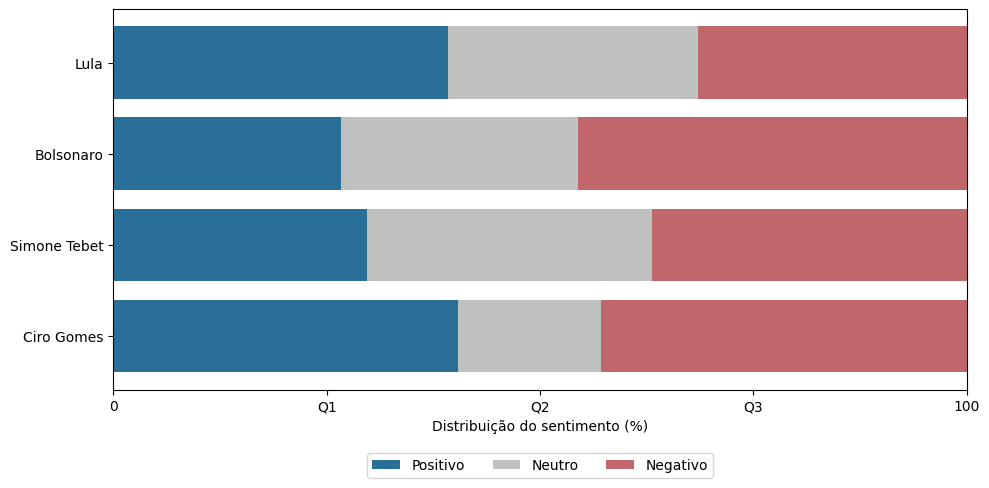

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "candidate": ["Lula", "Bolsonaro", "Simone Tebet", "Ciro Gomes"],
    "negative": [37412, 34439, 1527, 8526],
    "neutral": [34972, 21051, 1383, 3342],
    "positive": [46590, 20156, 1229, 8030],
    "total_mentions": [118974, 75646, 4139, 19898]
}

df_plot = pd.DataFrame(data)

# Convert counts into proportions
df_plot["negative_pct"] = df_plot["negative"] / df_plot["total_mentions"] * 100
df_plot["neutral_pct"] = df_plot["neutral"] / df_plot["total_mentions"] * 100
df_plot["positive_pct"] = df_plot["positive"] / df_plot["total_mentions"] * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    df_plot["candidate"],
    df_plot["positive_pct"],
    color="#2A6F97",
    label="Positivo"
)

ax.barh(
    df_plot["candidate"],
    df_plot["neutral_pct"],
    left=df_plot["positive_pct"],
    color="#BFC0C0",
    label="Neutro"
)

ax.barh(
    df_plot["candidate"],
    df_plot["negative_pct"],
    left=df_plot["positive_pct"] + df_plot["neutral_pct"],
    color="#C1666B",
    label="Negativo"
)

# Formatting
ax.set_xlabel("Distribuição do sentimento (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "Q1", "Q2", "Q3", "100"])



ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=3)

ax.invert_yaxis()  # keeps Lula at the top

plt.tight_layout()
plt.show()
